# **TASK 3 — Car Price Prediction with Machine Learning**

### **Objective:** Build a regression model that predicts the selling price of a used car based on features such as brand, age, mileage, fuel type, and transmission.


**Import Required Libraries**

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# LOAD DATASET
# ============================================

from google.colab import files

uploaded = files.upload()

Saving cardekho_task_3.csv to cardekho_task_3.csv


In [3]:
# Read the uploaded CSV file

df = pd.read_csv('cardekho_task_3.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display first 5 rows

df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [5]:
# Display last 5 rows

df.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [7]:
# Dataset dimensions

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8128
Number of columns: 12


In [8]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [9]:
# ============================================
# CHECK MISSING VALUES
# ============================================

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64


In [10]:
# Percentage of missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
})

missing_table.sort_values(by='Percentage (%)', ascending=False)

,Missing Values,Percentage (%)
seats,221,2.718996
mileage(km/ltr/kg),221,2.718996
engine,221,2.718996
max_power,215,2.645177
km_driven,0,0.000000
selling_price,0,0.000000
year,0,0.000000
name,0,0.000000
owner,0,0.000000
transmission,0,0.000000


In [11]:
# ============================================
# CHECK DUPLICATES
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1202


In [13]:
# Remove duplicate records

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (6926, 12)


In [14]:
# ============================================
# CLEAN CATEGORICAL VARIABLES
# ============================================

categorical_columns = [
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip().str.title()

print("Categorical values cleaned successfully!")

Categorical values cleaned successfully!


In [15]:
# Check unique values

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 fuel
['Diesel' 'Petrol' 'Lpg' 'Cng']

 seller_type
['Individual' 'Dealer' 'Trustmark Dealer']

 transmission
['Manual' 'Automatic']

 owner
['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']


In [16]:
# ============================================
# FEATURE ENGINEERING: CAR AGE
# ============================================

CURRENT_YEAR = 2026

df['car_age'] = CURRENT_YEAR - df['year']

df[['year', 'car_age']].head()

,year,car_age
0,2014,12
1,2014,12
2,2006,20
3,2010,16
4,2007,19


In [17]:
print("Minimum car age:", df['car_age'].min())
print("Maximum car age:", df['car_age'].max())

Minimum car age: 6
Maximum car age: 43


In [18]:
# ============================================
# EXTRACT CAR BRAND
# ============================================

df['brand'] = df['name'].str.split().str[0]

df[['name', 'brand']].head(10)

,name,brand
0,Maruti Swift Dzire VDI,Maruti
1,Skoda Rapid 1.5 TDI Ambition,Skoda
2,Honda City 2017-2020 EXi,Honda
3,Hyundai i20 Sportz Diesel,Hyundai
4,Maruti Swift VXI BSIII,Maruti
5,Hyundai Xcent 1.2 VTVT E Plus,Hyundai
6,Maruti Wagon R LXI DUO BSIII,Maruti
7,Maruti 800 DX BSII,Maruti
8,Toyota Etios VXD,Toyota
9,Ford Figo Diesel Celebration Edition,Ford


In [19]:
print("Number of unique brands:", df['brand'].nunique())

print("\nCar brands:")
print(df['brand'].unique())

Number of unique brands: 32

Car brands:
['Maruti' 'Skoda' 'Honda' 'Hyundai' 'Toyota' 'Ford' 'Renault' 'Mahindra'
 'Tata' 'Chevrolet' 'Fiat' 'Datsun' 'Jeep' 'Mercedes-Benz' 'Mitsubishi'
 'Audi' 'Volkswagen' 'BMW' 'Nissan' 'Lexus' 'Jaguar' 'Land' 'MG' 'Volvo'
 'Daewoo' 'Kia' 'Force' 'Ambassador' 'Ashok' 'Isuzu' 'Opel' 'Peugeot']


In [20]:
# ============================================
# CLEAN NUMERICAL FEATURES
# ============================================

# Convert max_power into numeric values
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce')

print(df[['max_power']].dtypes)

max_power    float64
dtype: object


In [21]:
# ============================================
# HANDLE MISSING NUMERICAL VALUES
# ============================================

numerical_columns = [
    'year',
    'selling_price',
    'km_driven',
    'mileage(km/ltr/kg)',
    'engine',
    'max_power',
    'seats',
    'car_age'
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing numerical values handled.")

Missing numerical values handled.


In [22]:
# ============================================
# REMOVE UNNECESSARY COLUMNS
# ============================================

df = df.drop(columns=['name', 'year'])

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age', 'brand']


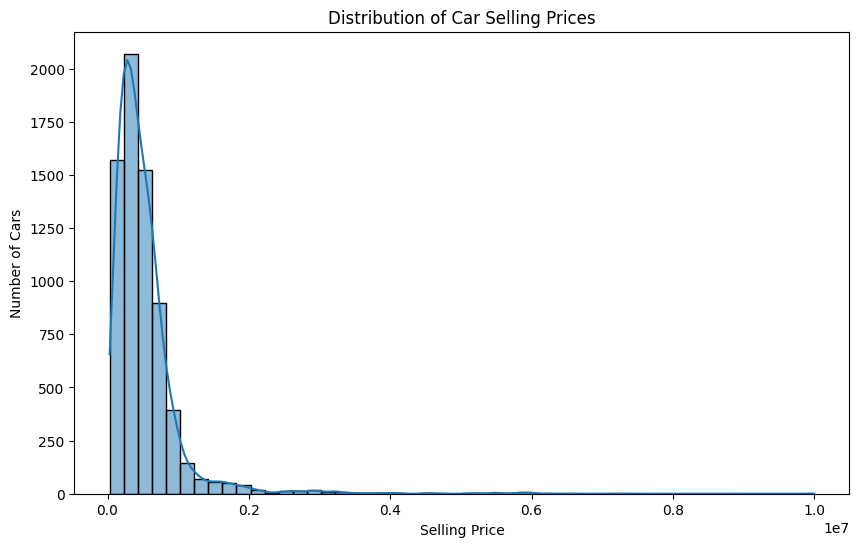

In [23]:
# ============================================
# DISTRIBUTION OF SELLING PRICE
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(df['selling_price'], bins=50, kde=True)

plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Number of Cars')

plt.show()

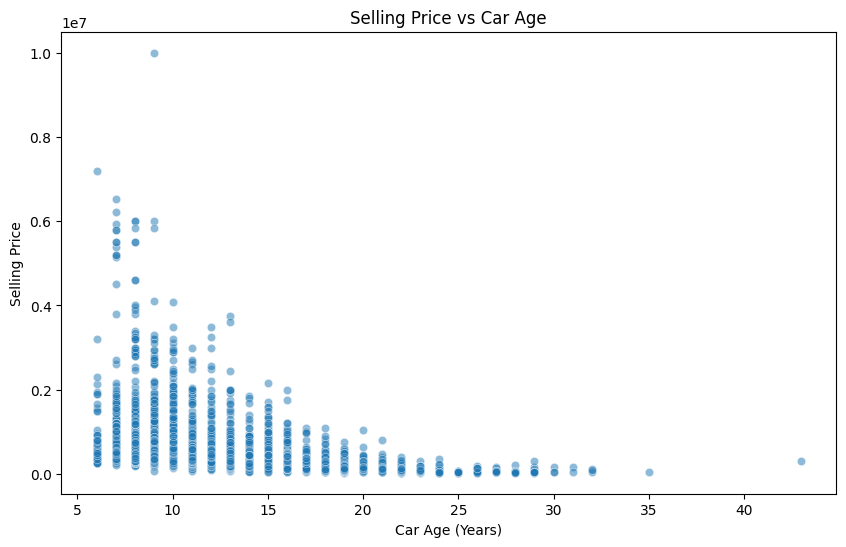

In [25]:
# ============================================
# SELLING PRICE VS CAR AGE
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='car_age',
    y='selling_price',
    alpha=0.5
)

plt.title('Selling Price vs Car Age')
plt.xlabel('Car Age (Years)')
plt.ylabel('Selling Price')

plt.show()

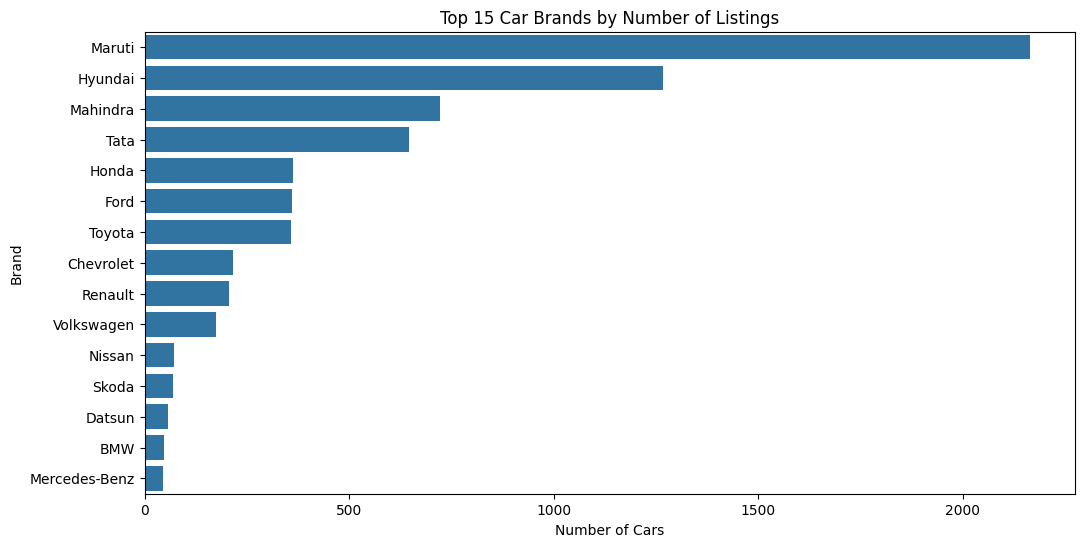

In [27]:
# ============================================
# TOP CAR BRANDS
# ============================================

top_brands = df['brand'].value_counts().head(15)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_brands.values,
    y=top_brands.index
)

plt.title('Top 15 Car Brands by Number of Listings')
plt.xlabel('Number of Cars')
plt.ylabel('Brand')

plt.show()

In [28]:
# ============================================
# DEFINE FEATURES AND TARGET
# ============================================

X = df.drop('selling_price', axis=1)

y = df['selling_price']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("selling_price")

Features:
['km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age', 'brand']

Target:
selling_price


In [29]:
# ============================================
# IDENTIFY FEATURE TYPES
# ============================================

categorical_features = X.select_dtypes(
    include=['object']
).columns.tolist()

numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['fuel', 'seller_type', 'transmission', 'owner', 'brand']

Numerical features:
['km_driven', 'mileage(km/ltr/kg)', 'engine', 'max_power', 'seats', 'car_age']


In [30]:
# ============================================
# TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5540
Testing samples: 1386


In [31]:
# ============================================
# PREPROCESSING PIPELINE
# ============================================

numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")



Preprocessing pipeline created successfully!


In [32]:
# ============================================
# MODEL 1: LINEAR REGRESSION
# ============================================

linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

# Train model
linear_model.fit(X_train, y_train)

# Predictions
linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [33]:
# ============================================
# EVALUATE LINEAR REGRESSION
# ============================================

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Performance
--------------------------------
MAE : 133098.53
RMSE: 261925.34
R²  : 0.6872


In [34]:
# ============================================
# MODEL 2: RANDOM FOREST REGRESSOR
# ============================================

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train model
random_forest_model.fit(X_train, y_train)

# Predictions
rf_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [35]:
# ============================================
# EVALUATE RANDOM FOREST
# ============================================

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")
print("--------------------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Performance
--------------------------------
MAE : 72912.17
RMSE: 127158.23
R²  : 0.9263


In [36]:
# ============================================
# MODEL 3: GRADIENT BOOSTING REGRESSOR
# ============================================

gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

# Train model
gradient_boosting_model.fit(X_train, y_train)

# Predictions
gb_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [37]:
# ============================================
# EVALUATE GRADIENT BOOSTING
# ============================================

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting Performance")
print("--------------------------------")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

Gradient Boosting Performance
--------------------------------
MAE : 81660.42
RMSE: 127735.84
R²  : 0.9256


In [38]:
# ============================================
# MODEL COMPARISON
# ============================================

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE': [
        linear_mae,
        rf_mae,
        gb_mae
    ],

    'RMSE': [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    'R2 Score': [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,133098.533351,261925.335126,0.687195
1,Random Forest,72912.173461,127158.227508,0.926276
2,Gradient Boosting,81660.415412,127735.837715,0.925605


In [39]:
results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
1,Random Forest,72912.173461,127158.227508,0.926276
2,Gradient Boosting,81660.415412,127735.837715,0.925605
0,Linear Regression,133098.533351,261925.335126,0.687195


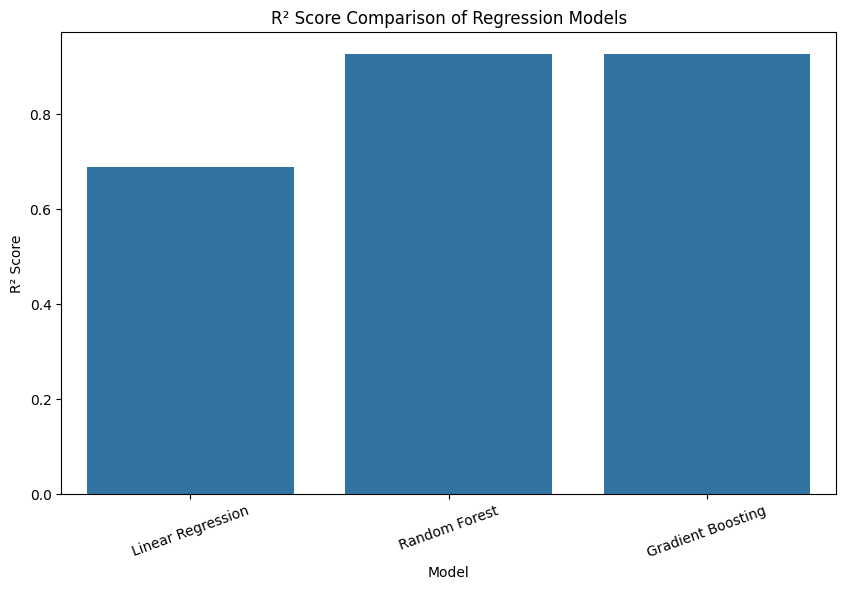

In [40]:
# ============================================
# MODEL PERFORMANCE COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results,
    x='Model',
    y='R2 Score'
)

plt.title('R² Score Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R² Score')

plt.xticks(rotation=20)

plt.show()